In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt


#Testando a conexão com o banco de dados e verificando os dados importados

# Conectando com o banco de dados e verificando os dados 
conexaoBanco = sqlite3.connect("../analise_impostos.db")

# Pegando número de registros por setor para verificar se os dados foram importados corretamente
query = "SELECT Setor, COUNT(*) as registros FROM despesas GROUP BY Setor"
dataFrameCheck = pd.read_sql_query(query, conexaoBanco)

print(dataFrameCheck)

                Setor  registros
0            Educação       1469
1  Previdência Social        247
2               Saúde        562
3   Segurança Pública         90
4         Transportes        214


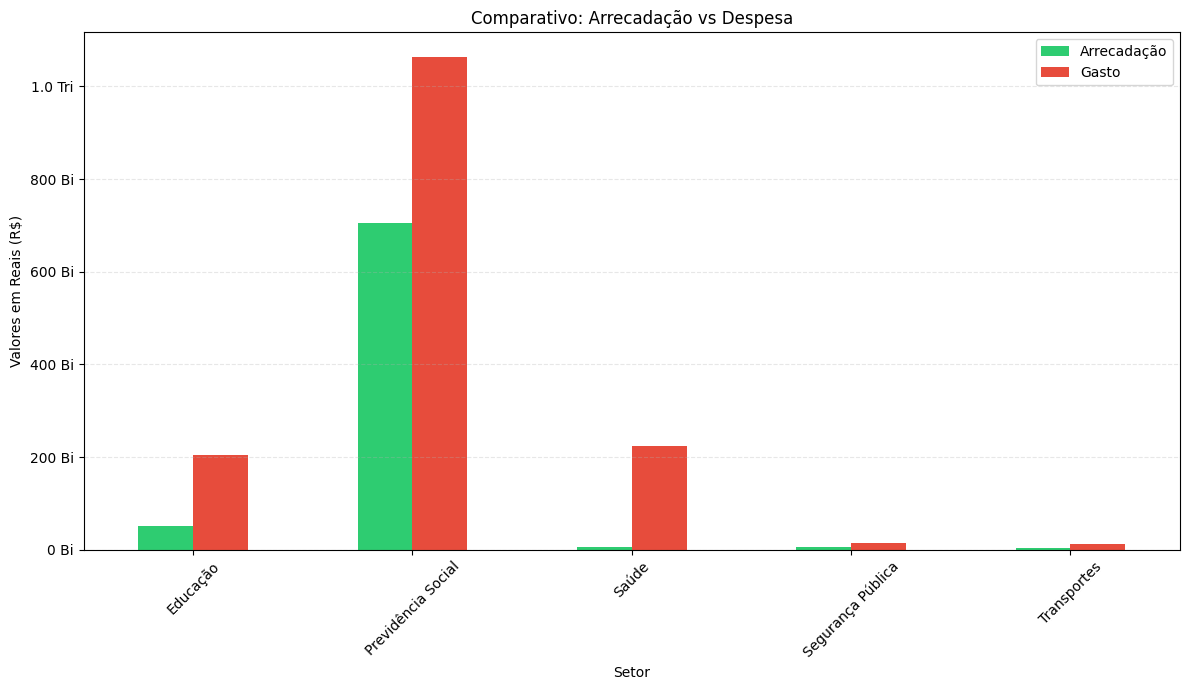

                Setor       totalArrecadado              totalGasto
0            Educação  R$ 51.625.341.265,24   R$ 204.744.841.299,01
1  Previdência Social R$ 704.876.207.719,45 R$ 1.063.415.975.696,21
2               Saúde   R$ 6.223.586.556,73   R$ 223.775.708.486,52
3   Segurança Pública   R$ 6.729.909.757,07    R$ 14.411.629.060,98
4         Transportes   R$ 3.210.381.507,75    R$ 12.829.348.957,86


In [2]:
# 1. Quais foram os valores arrecadados e gastos por setor? Como fica a comparação visual gráfico do balanço fiscal das 5 áreas públicas?
# IMPORTANTE: Sendo apenas do ano de 2025, não pegando valores de atrasados de anos anteriores.

import matplotlib.ticker as ticker # Biblioteca para formatar os eixos

#Captando query, aspas triplas para formar um bloco de linhas de códigos SQL
query = """
SELECT 
    r.Setor, 
    SUM(r."Receita Realizada (Valor Arrecadado)") as totalArrecadado,
    (SELECT SUM(d."Valor Pago") FROM despesas d WHERE d.Setor = r.Setor) as totalGasto
FROM receitas r
GROUP BY r.Setor
"""
tabela = pd.read_sql_query(query, conexaoBanco)

# 2. Criar o gráfico
fig, ax = plt.subplots(figsize=(12, 7)) #tamanho do gráfico 12 por 7 polegadas
tabela.plot(x='Setor', y=['totalArrecadado', 'totalGasto'], kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])

# 3. LÓGICA DE FORMATAÇÃO DO EIXO Y em Bilhoes e Trilhões 
def formatarEixo(valor, pos):
    if valor >= 1e12: # Se for 1 Trilhão ou mais
        return f'{valor*1e-12:.1f} Tri'
    else: # Se for Bilhões
        return f'{valor*1e-9:.0f} Bi'
    
# Aplicando a formatação personalizada ao eixo Y para captar valores em bilhões e trilhões
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatarEixo))

# 4. Ajustes finais
plt.title("Comparativo: Arrecadação vs Despesa")
plt.ylabel("Valores em Reais (R$)")
plt.xticks(rotation=45)
plt.legend(["Arrecadação", "Gasto"])
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print da tabela para conferência em formato brasileiro
pd.options.display.float_format = lambda x: 'R$ {:,.2f}'.format(x).replace(',', 'X').replace('.', ',').replace('X', '.')
print(tabela)


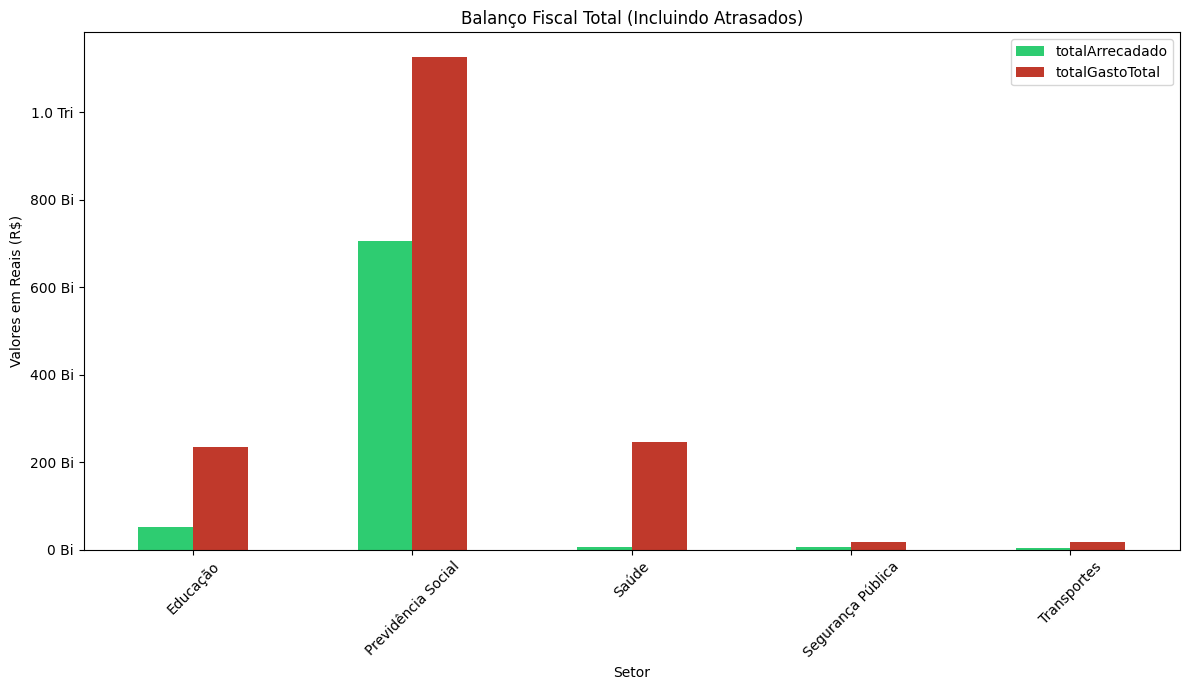

                Setor       totalArrecadado         totalGastoTotal
0            Educação  R$ 51.625.341.265,24   R$ 234.416.405.160,31
1  Previdência Social R$ 704.876.207.719,45 R$ 1.126.246.910.537,60
2               Saúde   R$ 6.223.586.556,73   R$ 246.335.524.960,62
3   Segurança Pública   R$ 6.729.909.757,07    R$ 17.850.502.831,04
4         Transportes   R$ 3.210.381.507,75    R$ 17.170.457.429,19


In [3]:
# 2. QUal a comparação despesas vs receitas, captando valores pagos em 2025 sendo de despesas anteriores a este período?

# Nova Query (Soma o Pago + Restos a Pagar), captando coluna valor restos a pagar pagos.
queryGastoTotal = """
SELECT 
    r.Setor, 
    SUM(r."Receita Realizada (Valor Arrecadado)") as totalArrecadado,
    (SELECT SUM(d."Valor Pago" + d."Valor Restos a Pagar Pagos") 
     FROM despesas d 
     WHERE d.Setor = r.Setor) as totalGastoTotal
FROM receitas r
GROUP BY r.Setor
"""
tabelaGastoTotal = pd.read_sql_query(queryGastoTotal, conexaoBanco)

# 2. Criar o novo gráfico
fig, ax = plt.subplots(figsize=(12, 7))
tabelaGastoTotal.plot(x='Setor', y=['totalArrecadado', 'totalGastoTotal'], kind='bar', ax=ax, color=['#2ecc71', '#c0392b'])

# 3. Aplicar a formatação 
ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatarEixo))

# 4. Ajustes finais
plt.title("Balanço Fiscal Total (Incluindo Atrasados)")
plt.ylabel("Valores em Reais (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(tabelaGastoTotal)


In [15]:
# Teste de sanidade para a Previdência Social
queryTeste = """
SELECT 
    SUM("Valor Pago") as apenasPago,
    SUM("Valor Restos a Pagar Pagos") as apenasRestos,
    SUM("Valor Pago" + "Valor Restos a Pagar Pagos") as somaTotal
FROM despesas 
WHERE Setor = 'Previdência Social'
"""
resultadoTeste = pd.read_sql_query(queryTeste, conexaoBanco)
print(resultadoTeste)



               apenasPago         apenasRestos               somaTotal
0 R$ 1.063.415.975.696,21 R$ 62.830.934.841,39 R$ 1.049.009.713.102,21
